### imports and settings

In [1]:
import pandas as pd
import time
from zero_shot_classification_utils import (
    run_zero_shot_classification,
    get_model_mismatches
)
from topic_modeling_utils import (
    get_topic_stats, 
    plot_quarterly_distribution
)

pd.set_option('display.max_colwidth', None)

In [2]:
abstracts_df = pd.read_pickle("abstracts_df.pkl")

### running a zero-shot classification (for previously defined labels)

In [3]:
labels = ['evolution', 'climate change', 'forests', 'biodiversity', 'soils']

In [9]:
%%time
zero_shot_batch1 = run_zero_shot_classification(abstracts_df[:400], 'abstract', labels)
zero_shot_batch1.to_pickle("zero_shot_batch1.pkl")

#CPU times: total: 1h 22min 53s
#Wall time: 1h 24min 47s

Device set to use cpu


CPU times: total: 1h 22min 53s
Wall time: 1h 24min 47s


In [15]:
%%time
zero_shot_batch2 = run_zero_shot_classification(abstracts_df[401:], 'abstract', labels)
zero_shot_batch2.to_pickle("zero_shot_batch2.pkl")

#CPU times: total: 1h 58min 58s
#Wall time: 2h 1min 53s

Device set to use cpu


CPU times: total: 1h 58min 58s
Wall time: 2h 1min 53s


In [4]:
#abstracts_zero_shot = pd.concat([zero_shot_batch1, zero_shot_batch2], ignore_index = True)
#abstracts_zero_shot.to_pickle("abstracts_zero_shot.pkl")

abstracts_zero_shot = pd.read_pickle("abstracts_zero_shot.pkl")

### results analysis

In [5]:
get_topic_stats(abstracts_zero_shot, col = 'top_choice')

,count,percent
top_choice,,
biodiversity,388,43.45
evolution,197,22.06
climate change,155,17.36
forests,113,12.65
soils,40,4.48


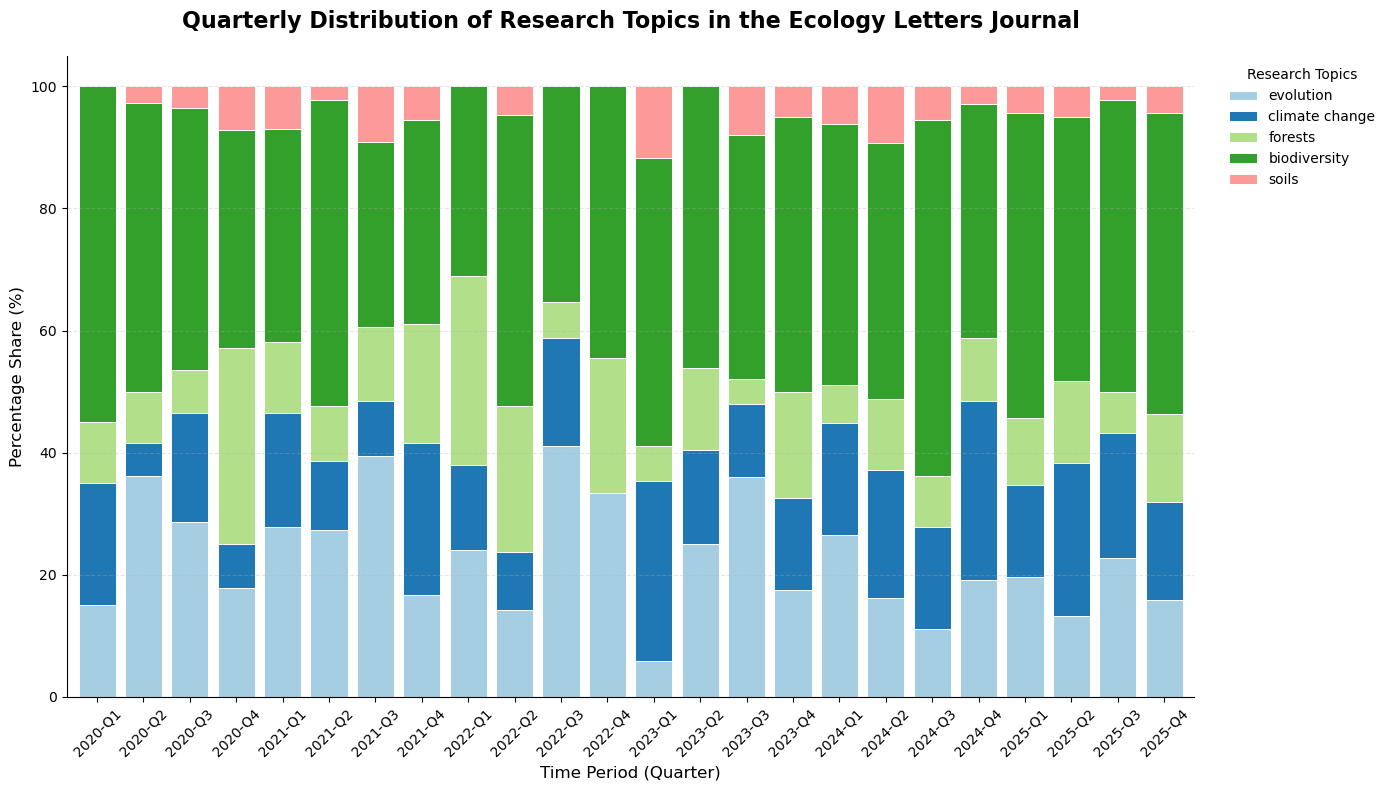

In [6]:
quarterly_distribution_zero_shot = plot_quarterly_distribution(df = abstracts_zero_shot, topic_names = labels, col = 'top_choice')

In [7]:
df_nmf = pd.read_pickle("abstracts_topics.pkl")
get_model_mismatches(df_nmf, abstracts_zero_shot, nmf_col='dominant_topic', zs_col='top_choice')

number or mismatches: 382.


,abstract,nmf_topic,zero_shot_topic
1,"Abstract In a rapidly changing world, quantifying ecosystem resilience is an important challenge. Historically, resilience has been defined via models that do not take spatial effects into account. These systems can only adapt via uniform adjustments. In reality, however, the response is not necessarily uniform, and can lead to the formation of (self‐organised) spatial patterns – typically localised vegetation patches. Classical measures of resilience cannot capture the emerging dynamics in spatially self‐organised systems, including transitions between patterned states that have limited impact on ecosystem structure and productivity. We present a framework of interlinked phase portraits that appropriately quantifies the resilience of patterned states, which depends on the number of patches, the distances between them and environmental conditions. We show how classical resilience concepts fail to distinguish between small and large pattern transitions, and find that the variance in interpatch distances provides a suitable indicator for the type of imminent transition. Subsequently, we describe the dependency of ecosystem degradation based on the rate of climatic change: slow change leads to sporadic, large transitions, whereas fast change causes a rapid sequence of smaller transitions. Finally, we discuss how pre‐emptive removal of patches can minimise productivity losses during pattern transitions, constituting a viable conservation strategy.",biodiversity,climate change
3,"Preventing malnutrition through consuming nutritionally appropriate resources represents a challenge for foraging animals. This is due to often high variation in the nutritional quality of available resources. Foragers consequently need to evaluate different food sources. However, even the same food source can provide a plethora of nutritional and non-nutritional cues, which could serve for quality assessment. We show that bumblebees, Bombus terrestris, overcome this challenge by relying on lipids as nutritional cue when selecting pollen. The bees 'prioritised' lipid perception in learning experiments and avoided lipid consumption in feeding experiments, which supported survival and reproduction. In contrast, survival and reproduction were severely reduced by increased lipid contents. Our study highlights the importance of fat regulation for pollen foraging bumblebees. It also reveals that nutrient perception, nutrient regulation and reproductive fitness can be linked, which represents an effective strategy enabling quick foraging decisions that prevent malnutrition and maximise fitness.",evolution,biodiversity
5,"Abstract Our understanding of ecological processes is built on patterns inferred from data. Applying modern analytical tools such as machine learning to increasingly high dimensional data offers the potential to expand our perspectives on these processes, shedding new light on complex ecological phenomena such as pathogen transmission in wild populations. Here, we propose a novel approach that combines data mining with theoretical models of disease dynamics. Using rodents as an example, we incorporate statistical differences in the life history features of zoonotic reservoir hosts into pathogen transmission models, enabling us to bound the range of dynamical phenomena associated with hosts, based on their traits. We then test for associations between equilibrium prevalence, a key epidemiological metric and data on human outbreaks of rodent‐borne zoonoses, identifying matches between empirical evidence and theoretical predictions of transmission dynamics. We show how this framework can be generalized to other systems through a rubric of disease models and parameters that can be derived from empirical data. By linking life history components directly to their effects on disease dynamics, our mining‐modelling approach integrates machine learning and theoretical models to explore mechanisms in the macroecology o